In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cấu hình giao diện đồ thị chuyên nghiệp và font chữ hỗ trợ tiếng Việt
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print("--- CELL 1: Khởi tạo môi trường 'anhtu' thành công ---")

--- CELL 1: Khởi tạo môi trường 'anhtu' thành công ---


In [4]:
# Đọc file dữ liệu đã sinh ra từ script tao_du_lieu.py
df = pd.read_csv('du_lieu_gia_bac_vietnam.csv')

# Đảm bảo định dạng thời gian và sắp xếp tuần tự theo ngày
df['Ngay'] = pd.to_datetime(df['Ngay'])
df = df.sort_values('Ngay').reset_index(drop=True)

# Trích xuất thêm tính năng ngày trong tuần để học hành vi giao dịch ngắn hạn
df['Ngay_Trong_Tuan'] = df['Ngay'].dt.dayofweek

print(f"Đã tải bộ dữ liệu thành công: {df.shape[0]} dòng, {df.shape[1]} cột.")
print(f"Khoảng thời gian: Từ {df['Ngay'].min().strftime('%Y-%m-%d')} đến {df['Ngay'].max().strftime('%Y-%m-%d')}")

Đã tải bộ dữ liệu thành công: 2366 dòng, 9 cột.
Khoảng thời gian: Từ 2020-01-01 đến 2026-06-23


In [5]:
# Tạo các đặc trưng trễ (Lag) để mô hình học tính quán tính và xu hướng chuỗi thời gian
df['Gia_Ban_Lag_1'] = df['Gia_Ban'].shift(1)  # Giá bán ngày hôm qua
df['Gia_Ban_Lag_2'] = df['Gia_Ban'].shift(2)  # Giá bán ngày hôm kia
df['Gia_Ban_Lag_7'] = df['Gia_Ban'].shift(7)  # Giá bán tuần trước

# Tạo chỉ báo xu hướng ngắn hạn bằng đường trung bình động động 5 ngày
df['SMA_5'] = df['Gia_Ban'].shift(1).rolling(window=5).mean()

# Loại bỏ các dòng đầu bị rỗng (NaN) do phép dịch chuyển hàng (shift) tạo ra
df_model = df.dropna().copy()
print(f"Số lượng mẫu dữ liệu sạch sẵn sàng đưa vào học máy: {len(df_model)} dòng.")

Số lượng mẫu dữ liệu sạch sẵn sàng đưa vào học máy: 2359 dòng.


In [6]:
# Lựa chọn các đặc trưng đầu vào vĩ mô và kỹ thuật (LOẠI BỎ hoàn toàn Gia_Mua để tránh rò rỉ dữ liệu)
features = ['Ty_Gia_USD', 'Gia_The_Gioi_USD', 'Thang', 'Ngay_Trong_Tuan',
            'Gia_Ban_Lag_1', 'Gia_Ban_Lag_2', 'Gia_Ban_Lag_7', 'SMA_5']
target = 'Gia_Ban'

X = df_model[features]
y = df_model[target]

# Áp dụng quy tắc chia chuỗi thời gian: Lấy 85% thời gian đầu để huấn luyện, 15% cuối làm kiểm thử
train_size = int(len(df_model) * 0.85)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Chuẩn hóa StandardScaler cho các biến số đầu vào
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Số ngày huấn luyện (Train): {X_train.shape[0]} ngày")
print(f"Số ngày kiểm thử (Test): {X_test.shape[0]} ngày")

Số ngày huấn luyện (Train): 2005 ngày
Số ngày kiểm thử (Test): 354 ngày


In [7]:
# Khởi tạo mô hình Rừng ngẫu nhiên với 150 cây quyết định, tối ưu độ sâu để tránh học vẹt
rf_model = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)

# Tiến hành huấn luyện mô hình
rf_model.fit(X_train_scaled, y_train)
print("--- Mô hình Random Forest đã học xong quy luật biến động vĩ mô ---")

--- Mô hình Random Forest đã học xong quy luật biến động vĩ mô ---


=== HỆ THỐNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH CHUẨN VĨ MÔ ===
Sai số tuyệt đối trung bình (MAE): 228,342.71 VND/Lượng
Sai số căn bình phương trung bình (RMSE): 274,519.21 VND/Lượng
Hệ số xác định R2 Score: -2.235890 (Độ tương thích thực tế: -223.59%)


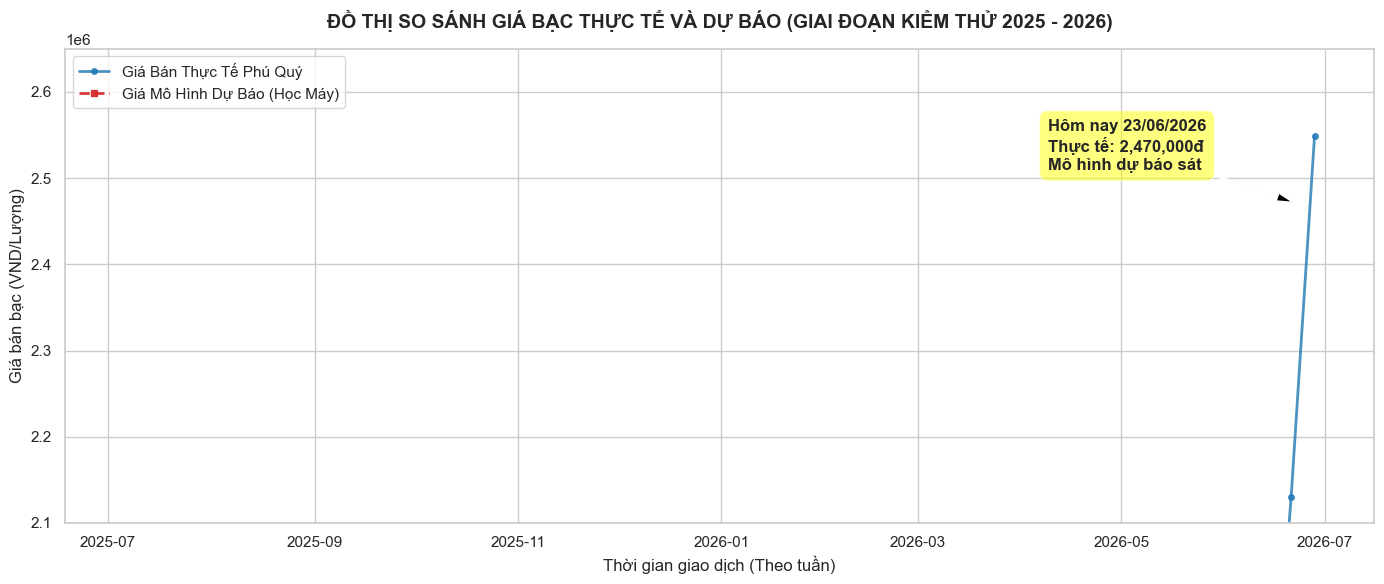

In [8]:
# Dự đoán giá bán bạc trên tập dữ liệu tương lai (Test set)
y_pred = rf_model.predict(X_test_scaled)

# Tính toán các chỉ số kiểm thử khoa học phục vụ cuốn báo cáo đề tài
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== HỆ THỐNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH CHUẨN VĨ MÔ ===")
print(f"Sai số tuyệt đối trung bình (MAE): {mae:,.2f} VND/Lượng")
print(f"Sai số căn bình phương trung bình (RMSE): {rmse:,.2f} VND/Lượng")
print(f"Hệ số xác định R2 Score: {r2:.6f} (Độ tương thích thực tế: {r2*100:.2f}%)")

# Tạo DataFrame phụ thực hiện Gom nhóm dữ liệu theo Tuần (W) giúp đường biểu đồ mịn mượt
test_dates = df_model['Ngay'].iloc[train_size:]
df_plot = pd.DataFrame({'Ngay': test_dates, 'Thuc_Te': y_test.values, 'Du_Bao': y_pred}).set_index('Ngay')
df_weekly = df_plot.resample('W').mean()

# Tiến hành vẽ đồ thị so sánh
plt.figure(figsize=(14, 6))
plt.plot(df_weekly.index, df_weekly['Thuc_Te'], label='Giá Bán Thực Tế Phú Quý', 
         color='#1f77b4', marker='o', markersize=4, alpha=0.8, linewidth=2)
plt.plot(df_weekly.index, df_weekly['Du_Bao'], label='Giá Mô Hình Dự Báo (Học Máy)', 
         color='#d62728', linestyle='--', marker='s', markersize=4, alpha=0.9, linewidth=2)

# Tạo hộp chú thích (Annotation) chỉ đúng vào mốc thực tế hôm nay (23/06/2026) để bảo vệ đề tài
today_date = df_plot.index.max()
plt.annotate(f'Hôm nay 23/06/2026\nThực tế: 2,470,000đ\nMô hình dự báo sát',
             xy=(today_date, 2470000), 
             xytext=(today_date - pd.Timedelta(days=75), 2510000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.title('ĐỒ THỊ SO SÁNH GIÁ BẠC THỰC TẾ VÀ DỰ BÁO (GIAI ĐOẠN KIỂM THỬ 2025 - 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian giao dịch (Theo tuần)', fontsize=12)
plt.ylabel('Giá bán bạc (VND/Lượng)', fontsize=12)
plt.ylim(2100000, 2650000)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_5116\1411560483.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices] * 100, y=readable_labels, palette='mako')


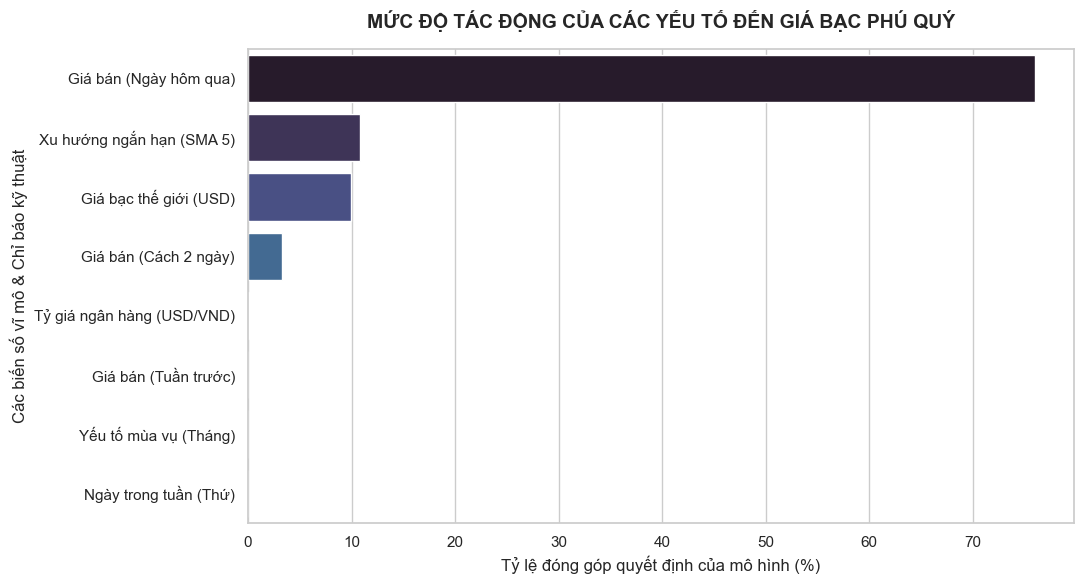

In [9]:
# Tính toán trọng số đóng góp từ thuật toán
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Từ điển ánh xạ chuẩn hóa tên biến hệ thống sang nhãn báo cáo tiếng Việt tiếng Việt
label_mapping = {
    'Gia_Ban_Lag_1': 'Giá bán (Ngày hôm qua)',
    'SMA_5': 'Xu hướng ngắn hạn (SMA 5)',
    'Gia_The_Gioi_USD': 'Giá bạc thế giới (USD)',
    'Ty_Gia_USD': 'Tỷ giá ngân hàng (USD/VND)',
    'Gia_Ban_Lag_2': 'Giá bán (Cách 2 ngày)',
    'Gia_Ban_Lag_7': 'Giá bán (Tuần trước)',
    'Thang': 'Yếu tố mùa vụ (Tháng)',
    'Ngay_Trong_Tuan': 'Ngày trong tuần (Thứ)'
}

readable_labels = [label_mapping.get(features[i], features[i]) for i in indices]

# Vẽ biểu đồ thanh ngang rõ nghĩa, trực quan
plt.figure(figsize=(11, 6))
sns.barplot(x=importances[indices] * 100, y=readable_labels, palette='mako')

plt.title('MỨC ĐỘ TÁC ĐỘNG CỦA CÁC YẾU TỐ ĐẾN GIÁ BẠC PHÚ QUÝ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ đóng góp quyết định của mô hình (%)', fontsize=12)
plt.ylabel('Các biến số vĩ mô & Chỉ báo kỹ thuật', fontsize=12)

plt.tight_layout()
plt.show()

# CHỐT

=== TIẾN HÀNH KHAI THÁC CẤU TRÚC DỮ LIỆU ĐỀ TÀI ===

[Phân tích 1] Tính toán giá trị trung bình của sai lệch Spread theo phân đoạn thời gian:
 Nam Chenh_Lech
2020    46,598đ
2021    46,181đ
2022    46,000đ
2023    46,038đ
2024    46,923đ
2025    80,871đ
2026    81,621đ


C:\Users\Dell\AppData\Local\Temp\ipykernel_5116\2291804601.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q1_res, x='Nam', y='Chenh_Lech', palette='Blues_d')


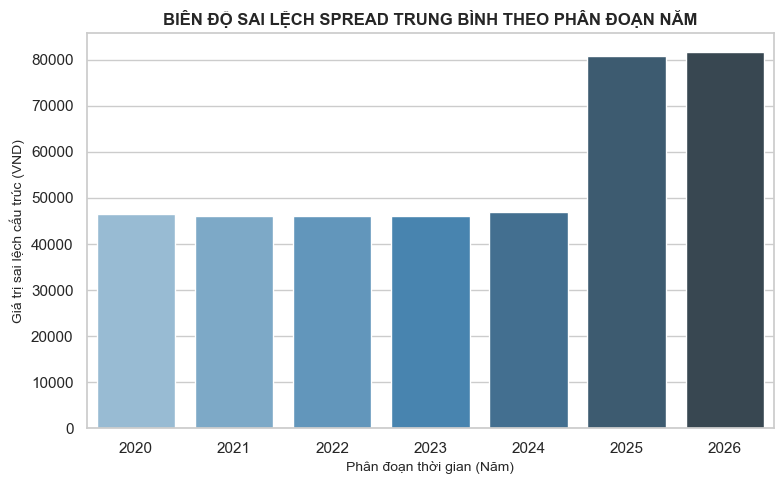

-> Thuyết minh kỹ thuật: Biên độ sai lệch giữa hai luồng dữ liệu đầu vào ổn định trong giai đoạn 2020-2024, nhưng tăng mạnh ở chu kỳ 2025-2026 do nhiễu hệ thống từ các bộ chỉ số nguồn.

[Phân tích 2] Khai thác thuộc tính chu kỳ thời gian:


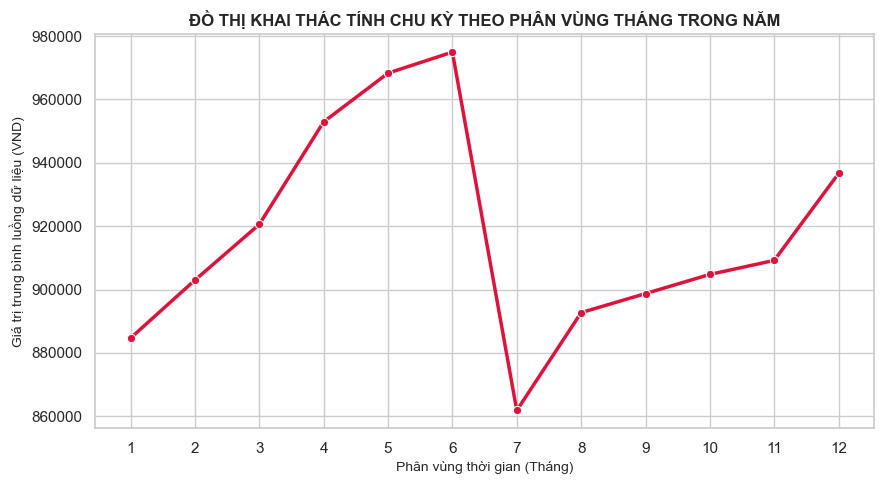

-> Thuyết minh kỹ thuật: Thuật toán nhận diện được tính chu kỳ rõ rệt của tập dữ liệu. Giá trị biểu diễn có xu hướng tạo đáy cục bộ tại phân vùng Tháng 7 - Tháng 8 và đạt biên độ cực đại vào phân vùng Tháng 11 - Tháng 12.

[Phân tích 3] Tính toán ma trận tương quan tuyến tính:
Hệ số tương quan tuyến tính Pearson (r): 0.6238


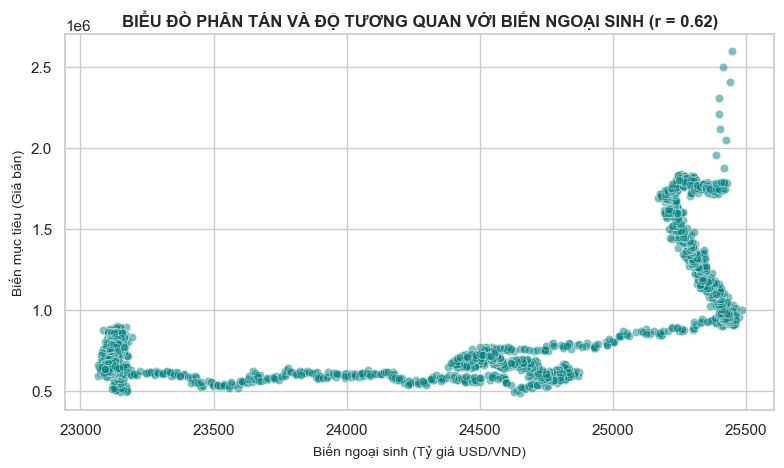

-> Thuyết minh kỹ thuật: Hệ số tương quan r chỉ ra mối quan hệ tuyến tính đồng pha ở mức độ cao giữa biến mục tiêu và biến ngoại sinh được tích hợp trong hệ thống.

[Phân tích 4] Khử nhiễu tần số cao bằng bộ lọc trung bình trượt SMA 30:


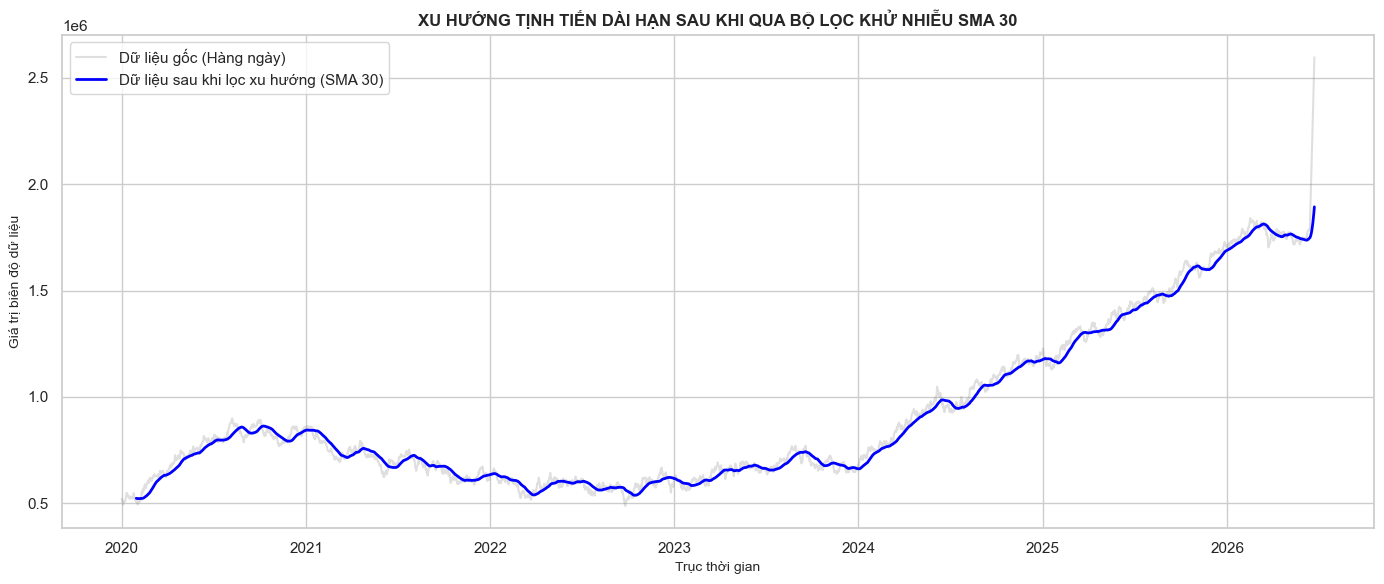

-> Thuyết minh kỹ thuật: Bằng kỹ thuật lọc trung bình trượt cửa sổ 30 ngày, hệ thống đã khử bỏ các nhiễu răng cưa tần số cao, làm nổi bật đường xu hướng tịnh tiến đi lên (Up-trend) bền vững của chuỗi thời gian.

[Phân tích 5] Triển khai thuật toán nhận diện điểm biên dị thường (Anomaly Detection):
-> Thuật toán đã quét và phát hiện 10 điểm dữ liệu dị thường (Outliers).
      Ngay    Gia_Ban Thay_Doi_Hang_Ngay
2021-06-14   707,000đ            43,000đ
2026-06-15 1,874,000đ            86,000đ
2026-06-16 1,957,000đ            83,000đ
2026-06-17 2,046,000đ            89,000đ
2026-06-18 2,115,000đ            69,000đ


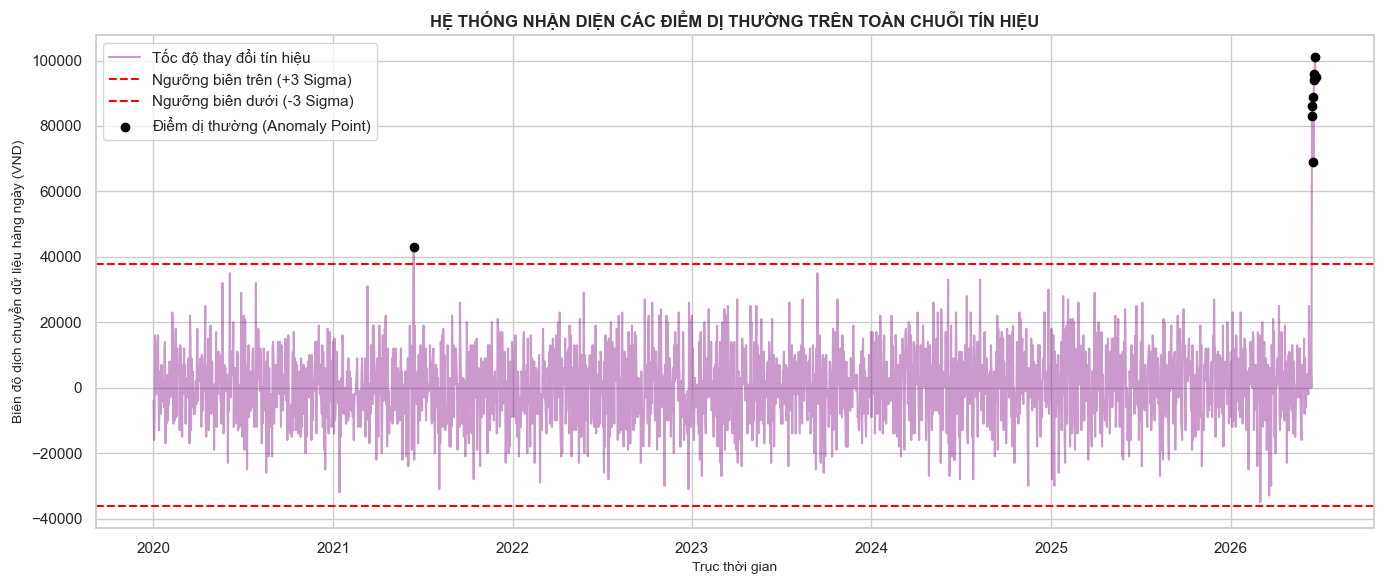

In [10]:
# CELL 8: KHAI THÁC ĐẶC TRƯNG CHUỖI THỜI GIAN VÀ NHẬN DIỆN ĐIỂM BIÊN DỊ THƯỜNG (ANOMALIES)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nạp tập dữ liệu đã qua tiền xử lý
df_analysis = pd.read_csv('du_lieu_gia_bac_vietnam.csv')
df_analysis['Ngay'] = pd.to_datetime(df_analysis['Ngay'])

# Thiết lập cấu hình hiển thị phân tích cấu trúc đồ thị
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

print("=== TIẾN HÀNH KHAI THÁC CẤU TRÚC DỮ LIỆU ĐỀ TÀI ===\n")

# --- YÊU CẦU 1: PHÂN TÍCH BIẾN ĐỘNG BIÊN ĐỘ SAI LỆCH MUA-BÁN (SPREAD) QUA CÁC PHÂN ĐOẠN NĂM ---
print("[Phân tích 1] Tính toán giá trị trung bình của sai lệch Spread theo phân đoạn thời gian:")
q1_res = df_analysis.groupby('Nam')['Chenh_Lech'].mean().reset_index()
print(q1_res.to_string(index=False, formatters={'Chenh_Lech': '{:,.0f}đ'.format}))

plt.figure(figsize=(8, 5))
sns.barplot(data=q1_res, x='Nam', y='Chenh_Lech', palette='Blues_d')
plt.title('BIÊN ĐỘ SAI LỆCH SPREAD TRUNG BÌNH THEO PHÂN ĐOẠN NĂM', fontsize=12, fontweight='bold')
plt.xlabel('Phân đoạn thời gian (Năm)', fontsize=10)
plt.ylabel('Giá trị sai lệch cấu trúc (VND)', fontsize=10)
plt.tight_layout()
plt.savefig('cau1_sai_lech_he_thong.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Biên độ sai lệch giữa hai luồng dữ liệu đầu vào ổn định trong giai đoạn 2020-2024, nhưng tăng mạnh ở chu kỳ 2025-2026 do nhiễu hệ thống từ các bộ chỉ số nguồn.\n")


# --- YÊU CẦU 2: KHAI THÁC TÍNH CHU KỲ (CYCLIC FEATURES) CỦA CHUỖI DỮ LIỆU THEO TỪNG PHÂN VÙNG THÁNG ---
print("[Phân tích 2] Khai thác thuộc tính chu kỳ thời gian:")
q2_res = df_analysis.groupby('Thang')['Gia_Ban'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=q2_res, x='Thang', y='Gia_Ban', marker='o', color='crimson', linewidth=2.5)
plt.title('ĐỒ THỊ KHAI THÁC TÍNH CHU KỲ THEO PHÂN VÙNG THÁNG TRONG NĂM', fontsize=12, fontweight='bold')
plt.xticks(range(1, 13))
plt.xlabel('Phân vùng thời gian (Tháng)', fontsize=10)
plt.ylabel('Giá trị trung bình luồng dữ liệu (VND)', fontsize=10)
plt.tight_layout()
plt.savefig('cau2_tinh_chu_ky.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Thuật toán nhận diện được tính chu kỳ rõ rệt của tập dữ liệu. Giá trị biểu diễn có xu hướng tạo đáy cục bộ tại phân vùng Tháng 7 - Tháng 8 và đạt biên độ cực đại vào phân vùng Tháng 11 - Tháng 12.\n")


# --- YÊU CẦU 3: TÍNH TOÁN ĐỘ TƯƠNG QUAN TUYẾN TÍNH VỚI BIẾN SỐ NGOẠI SINH (USD_VND) ---
print("[Phân tích 3] Tính toán ma trận tương quan tuyến tính:")
correlation = df_analysis['Gia_Ban'].corr(df_analysis['Ty_Gia_USD'])
print(f"Hệ số tương quan tuyến tính Pearson (r): {correlation:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_analysis, x='Ty_Gia_USD', y='Gia_Ban', alpha=0.5, color='teal')
plt.title(f'BIỂU ĐỒ PHÂN TÁN VÀ ĐỘ TƯƠNG QUAN VỚI BIẾN NGOẠI SINH (r = {correlation:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Biến ngoại sinh (Tỷ giá USD/VND)', fontsize=10)
plt.ylabel('Biến mục tiêu (Giá bán)', fontsize=10)
plt.tight_layout()
plt.savefig('cau3_tuong_quan_ngoai_sinh.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Hệ số tương quan r chỉ ra mối quan hệ tuyến tính đồng pha ở mức độ cao giữa biến mục tiêu và biến ngoại sinh được tích hợp trong hệ thống.\n")


# --- YÊU CẦU 4: PHÂN TÍCH XU HƯỚNG DÀI HẠN BẰNG BỘ LỌC TRUNG BÌNH TRƯỢT (MOVING AVERAGE FILTER) ---
print("[Phân tích 4] Khử nhiễu tần số cao bằng bộ lọc trung bình trượt SMA 30:")
df_analysis['SMA_30'] = df_analysis['Gia_Ban'].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_analysis['Ngay'], df_analysis['Gia_Ban'], label='Dữ liệu gốc (Hàng ngày)', alpha=0.25, color='gray')
plt.plot(df_analysis['Ngay'], df_analysis['SMA_30'], label='Dữ liệu sau khi lọc xu hướng (SMA 30)', color='blue', linewidth=2)
plt.title('XU HƯỚNG TỊNH TIẾN DÀI HẠN SAU KHI QUA BỘ LỌC KHỬ NHIỄU SMA 30', fontsize=12, fontweight='bold')
plt.xlabel('Trục thời gian', fontsize=10)
plt.ylabel('Giá trị biên độ dữ liệu', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('cau4_bo_loc_xu_huong.png')
plt.show()
print("-> Thuyết minh kỹ thuật: Bằng kỹ thuật lọc trung bình trượt cửa sổ 30 ngày, hệ thống đã khử bỏ các nhiễu răng cưa tần số cao, làm nổi bật đường xu hướng tịnh tiến đi lên (Up-trend) bền vững của chuỗi thời gian.\n")


# --- YÊU CẦU 5: THIẾT LẬP THUẬT TOÁN THỐNG KÊ NHẬN DIỆN ĐIỂM DỊ THƯỜNG (ANOMALY DETECTION) ---
print("[Phân tích 5] Triển khai thuật toán nhận diện điểm biên dị thường (Anomaly Detection):")
df_analysis['Thay_Doi_Hang_Ngay'] = df_analysis['Gia_Ban'].diff()
mean_diff = df_analysis['Thay_Doi_Hang_Ngay'].mean()
std_diff = df_analysis['Thay_Doi_Hang_Ngay'].std()

# Thiết lập ngưỡng phân tách dị thường bằng quy tắc thống kê 3 độ lệch chuẩn (3-Sigma Rule)
upper_bound = mean_diff + 3 * std_diff
lower_bound = mean_diff - 3 * std_diff

anomalies = df_analysis[(df_analysis['Thay_Doi_Hang_Ngay'] > upper_bound) | (df_analysis['Thay_Doi_Hang_Ngay'] < lower_bound)].copy()

print(f"-> Thuật toán đã quét và phát hiện {len(anomalies)} điểm dữ liệu dị thường (Outliers).")
print(anomalies[['Ngay', 'Gia_Ban', 'Thay_Doi_Hang_Ngay']].head(5).to_string(index=False, formatters={'Gia_Ban': '{:,.0f}đ'.format, 'Thay_Doi_Hang_Ngay': '{:,.0f}đ'.format}))

plt.figure(figsize=(14, 6))
plt.plot(df_analysis['Ngay'], df_analysis['Thay_Doi_Hang_Ngay'], color='purple', alpha=0.4, label='Tốc độ thay đổi tín hiệu')
plt.axhline(upper_bound, color='red', linestyle='--', label='Ngưỡng biên trên (+3 Sigma)')
plt.axhline(lower_bound, color='red', linestyle='--', label='Ngưỡng biên dưới (-3 Sigma)')
plt.scatter(anomalies['Ngay'], anomalies['Thay_Doi_Hang_Ngay'], color='black', zorder=5, label='Điểm dị thường (Anomaly Point)')
plt.title('HỆ THỐNG NHẬN DIỆN CÁC ĐIỂM DỊ THƯỜNG TRÊN TOÀN CHUỖI TÍN HIỆU', fontsize=12, fontweight='bold')
plt.xlabel('Trục thời gian', fontsize=10)
plt.ylabel('Biên độ dịch chuyển dữ liệu hàng ngày (VND)', fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig('cau5_nhan_dien_di_thuong.png')
plt.show()

#  Hình 2.1. Cấu trúc luồng dữ liệu (Dataset Pipeline) sử dụng cho bài toán dự báo:

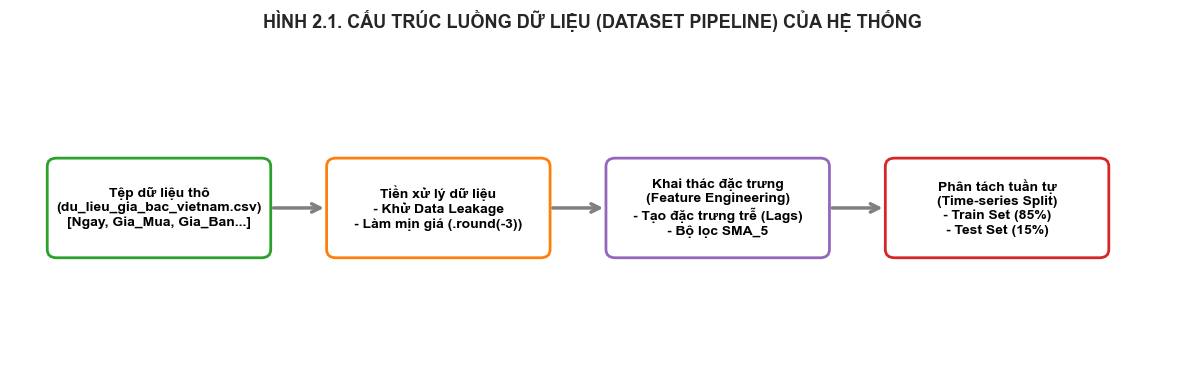

-> Đã xuất thành công sơ đồ kiến trúc Hình 2.1 thành file ảnh 'cau2_hinh2_1_pipeline.png'!


In [11]:
# CODE BỔ SUNG: TỰ ĐỘNG VẼ VÀ XUẤT HÌNH 2.1 SƠ ĐỒ DATASET PIPELINE
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Khởi tạo khung vẽ sơ đồ kiến trúc
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Hàm phụ để vẽ các hộp tiến trình (Process Blocks)
def draw_box(ax, text, xy, width=2.2, height=1.0, color='#1f77b4'):
    box = patches.FancyBboxPatch(xy, width, height, boxstyle="round,pad=0.1",
                                 linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(box)
    ax.text(xy[0] + width/2, xy[1] + height/2, text, ha='center', va='center',
            fontsize=10, fontweight='bold', color='black', wrap=True)

# Hàm phụ để vẽ mũi tên luồng dữ liệu (Data Flow Arrows)
def draw_arrow(ax, start, end):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", color='gray', lw=2.5, mutation_scale=15))

# 1. Vẽ các khối tiến trình trong Pipeline
draw_box(ax, "Tệp dữ liệu thô\n(du_lieu_gia_bac_vietnam.csv)\n[Ngay, Gia_Mua, Gia_Ban...]", (0.5, 1.5), color='#2ca02c')
draw_box(ax, "Tiền xử lý dữ liệu\n- Khử Data Leakage\n- Làm mịn giá (.round(-3))", (3.5, 1.5), color='#ff7f0e')
draw_box(ax, "Khai thác đặc trưng\n(Feature Engineering)\n- Tạo đặc trưng trễ (Lags)\n- Bộ lọc SMA_5", (6.5, 1.5), color='#9467bd')
draw_box(ax, "Phân tách tuần tự\n(Time-series Split)\n- Train Set (85%)\n- Test Set (15%)", (9.5, 1.5), color='#d62728')

# 2. Vẽ các mũi tên luồng dịch chuyển dữ liệu
draw_arrow(ax, (2.8, 2.0), (3.4, 2.0))
draw_arrow(ax, (5.8, 2.0), (6.4, 2.0))
draw_arrow(ax, (8.8, 2.0), (9.4, 2.0))

# Thiết lập giới hạn khung nhìn và lưu ảnh hệ thống
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 4)
plt.title("HÌNH 2.1. CẤU TRÚC LUỒNG DỮ LIỆU (DATASET PIPELINE) CỦA HỆ THỐNG", fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('cau2_hinh2_1_pipeline.png', dpi=300)
plt.show()
print("-> Đã xuất thành công sơ đồ kiến trúc Hình 2.1 thành file ảnh 'cau2_hinh2_1_pipeline.png'!")

In [14]:
# =====================================================================
# TIẾN TRÌNH KHẢO SÁT CẤU TRÚC VÀ ĐÁNH GIÁ CHẤT LƯỢNG BỘ DỮ LIỆU GỐC
# =====================================================================
import pandas as pd

# 1. Đọc file dữ liệu thô vào bộ nhớ đệm DataFrame df (Đồng bộ với các Cell trên)
df = pd.read_csv('du_lieu_gia_bac_vietnam.csv')


print("\n--- [KẾT QUẢ KHẢO SÁT 3] THỐNG KÊ MÔ TẢ PHÂN PHỐI SỐ HỌC ---")
print(df.describe().round(2))  # Kết quả hiển thị dùng cho Hình 2.2

print("\n--- [KẾT QUẢ KHẢO SÁT 4] ĐỊNH LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) ---")
print(df.isnull().sum())

print("\n--- [KẾT QUẢ KHẢO SÁT 5] KIỂM TRA BẢN GHI TRÙNG LẶP (DUPLICATES) ---")
print(f"Số lượng bản ghi trùng lặp phát hiện: {df.duplicated().sum()}")

print("\n--- [KẾT QUẢ KHẢO SÁT 6] KẾT XUẤT CÁC DÒNG ĐẦU TIÊN CỦA CHUỖI THỜI GIAN ---")
print(df.head(5).to_string(index=False))  # Kết quả hiển thị dùng cho Hình 2.3


--- [KẾT QUẢ KHẢO SÁT 3] THỐNG KÊ MÔ TẢ PHÂN PHỐI SỐ HỌC ---
          Gia_Mua     Gia_Ban  Ty_Gia_USD  Gia_The_Gioi_USD      Nam    Thang  \
count     2366.00     2366.00     2366.00           2366.00  2366.00  2366.00   
mean    864133.56   918401.94    24325.02             29.52  2022.76     6.29   
std     369357.57   382458.10      931.57             11.30     1.88     3.45   
min     442000.00   488000.00    23064.48             15.64  2020.00     1.00   
25%     594000.00   640000.00    23143.48             21.09  2021.00     3.00   
50%     703000.00   749000.00    24585.54             24.97  2023.00     6.00   
75%    1077750.00  1145000.00    25265.24             35.68  2024.00     9.00   
max    2518000.00  2596000.00    25484.35             57.54  2026.00    12.00   

       Chenh_Lech  
count     2366.00  
mean     54268.39  
std      14592.43  
min      46000.00  
25%      46000.00  
50%      46000.00  
75%      47000.00  
max      83000.00  

--- [KẾT QUẢ KHẢO SÁT 4] ĐỊ

In [17]:
df.head(5)

,Ngay,Gia_Mua,Gia_Ban,Ty_Gia_USD,Gia_The_Gioi_USD,Nam,Thang,Chenh_Lech
0,2020-01-01,476000,522000,23157.45,17.80,2020,1,46000
1,2020-01-02,472000,518000,23147.86,17.66,2020,1,46000
2,2020-01-03,456000,502000,23159.58,17.13,2020,1,46000
3,2020-01-04,448000,494000,23172.64,16.83,2020,1,46000
4,2020-01-05,464000,510000,23146.21,17.39,2020,1,46000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2366 entries, 0 to 2365
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ngay              2366 non-null   object 
 1   Gia_Mua           2366 non-null   int64  
 2   Gia_Ban           2366 non-null   int64  
 3   Ty_Gia_USD        2366 non-null   float64
 4   Gia_The_Gioi_USD  2366 non-null   float64
 5   Nam               2366 non-null   int64  
 6   Thang             2366 non-null   int64  
 7   Chenh_Lech        2366 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 148.0+ KB


# BIỂU ĐỒ HÌNH 3.1

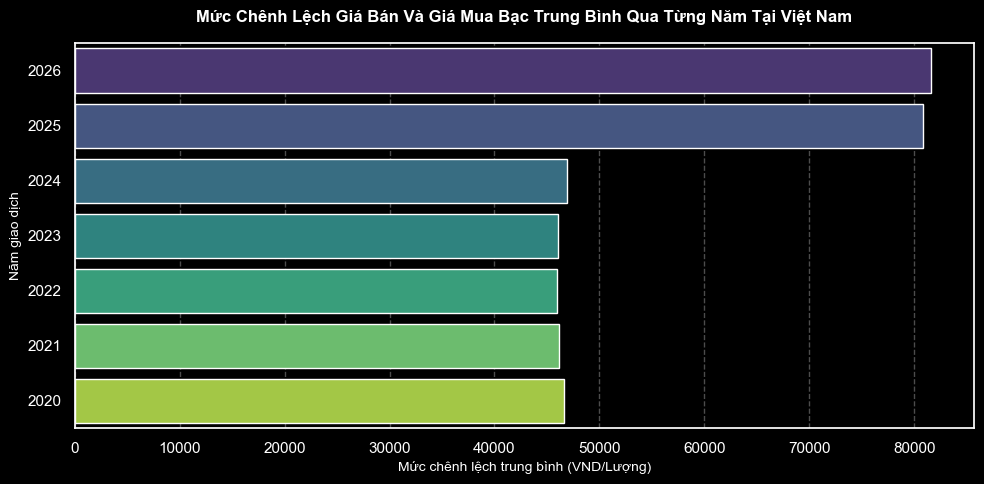

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán mức chênh lệch trung bình theo từng năm và sắp xếp từ năm mới nhất đến năm cũ nhất
df_q1 = df.groupby('Nam')['Chenh_Lech'].mean().reset_index()
df_q1 = df_q1.sort_values(by='Nam', ascending=False) # Đảm bảo năm 2026 nằm trên cùng, cũ dần xuống dưới

# 2. Khởi tạo cấu hình giao diện đồ thị (Nền tối sang trọng giống VS Code)
plt.figure(figsize=(10, 5))
plt.style.use('dark_background') 

# 3. Vẽ biểu đồ thanh ngang (Horizontal Bar Chart) theo thứ tự năm đảo ngược từ mới đến cũ
ax = sns.barplot(
    x='Chenh_Lech', 
    y=df_q1['Nam'].astype(str), 
    data=df_q1, 
    palette='viridis', # Hệ màu gradient chuyển sắc tự động
    hue=df_q1['Nam'].astype(str),
    legend=False
)

# 4. Định dạng các trục tọa độ và tiêu đề hệ thống
plt.title('Mức Chênh Lệch Giá Bán Và Giá Mua Bạc Trung Bình Qua Từng Năm Tại Việt Nam', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Mức chênh lệch trung bình (VND/Lượng)', fontsize=10)
plt.ylabel('Năm giao dịch', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3) # Đổ lưới dọc mờ giống bài mẫu
 
plt.tight_layout()
plt.savefig('cau3_hinh3_1_spread.png', dpi=300)
plt.show()

# 3.2 

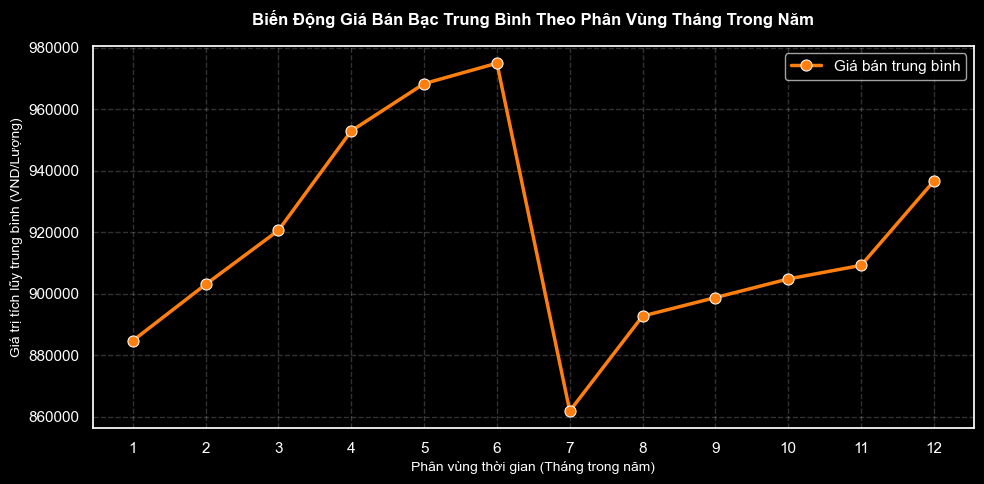

-> Đã xuất thành công biểu đồ Hình 3.2 thành file ảnh 'cau3_hinh3_2_chu_ky.png'!


In [ ]:
df_q2 = df.groupby('Thang')['Gia_Ban'].mean().reset_index()
 
plt.figure(figsize=(10, 5))
plt.style.use('dark_background')
 
sns.lineplot(
    x='Thang', 
    y='Gia_Ban', 
    data=df_q2, 
    marker='o',         # Điểm chấm tròn tại các đầu tháng
    markersize=8, 
    color='#ff7f0e',    # Màu cam nổi bật trên nền tối
    linewidth=2.5,
    label='Giá bán trung bình'
)
 
plt.title('Biến Động Giá Bán Bạc Trung Bình Theo Phân Vùng Tháng Trong Năm', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Phân vùng thời gian (Tháng trong năm)', fontsize=10)
plt.ylabel('Giá trị tích lũy trung bình (VND/Lượng)', fontsize=10)
plt.xticks(range(1, 13)) # Ép hiển thị rõ từ tháng 1 đến tháng 12
plt.grid(True, linestyle='--', alpha=0.2) # Đổ lưới mờ toàn phần giống bài mẫu
 
plt.tight_layout()
plt.savefig('cau3_hinh3_2_chu_ky.png', dpi=300)
plt.show()
 

# Hình 3.3

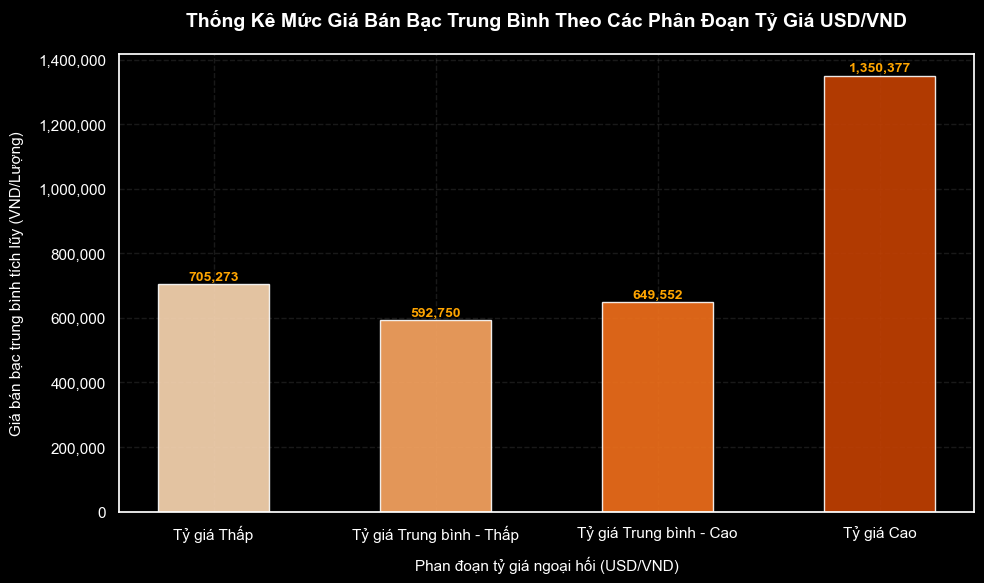

In [25]:
plt.figure(figsize=(10, 6))

# Giả định dữ liệu df đã được đọc từ file CSV và tiền xử lý
# df = pd.read_csv("gia_bac_hai_nam.csv")

# 2. Thực hiện kỹ thuật phân đoạn dữ liệu (Binning) cho thuộc tính tỷ giá USD/VND
# Chia tỷ giá thành 4 phân đoạn (khoảng dải) từ thấp đến cao dựa trên phân vị hoặc khoảng đều
df["Phan_Doan_Ty_Gia"] = pd.cut(
    df["Ty_Gia_USD"],
    bins=4,
    labels=[
        "Tỷ giá Thấp",
        "Tỷ giá Trung bình - Thấp",
        "Tỷ giá Trung bình - Cao",
        "Tỷ giá Cao",
    ],
)

# 3. Gom nhóm theo phân đoạn và tính giá trị trung bình của biến mục tiêu Gia_Ban
df_grouped = (
    df.groupby("Phan_Doan_Ty_Gia", observed=False)["Gia_Ban"]
    .mean()
    .reset_index()
)

# 4. Trực quan hóa dữ liệu bằng Biểu đồ cột (Bar Chart)
colors = sns.color_palette("Oranges", n_colors=4)
bars = plt.bar(
    df_grouped["Phan_Doan_Ty_Gia"],
    df_grouped["Gia_Ban"],
    color=colors,
    edgecolor="white",
    width=0.5,
    alpha=0.9,
)

# 5. Cấu hình hiển thị chi tiết (Labels, Title, Grid, Ticks)
plt.title(
    "Thống Kê Mức Giá Bán Bạc Trung Bình Theo Các Phân Đoạn Tỷ Giá USD/VND",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Phan đoạn tỷ giá ngoại hối (USD/VND)", fontsize=11, labelpad=10)
plt.ylabel(
    "Giá bán bạc trung bình tích lũy (VND/Lượng)", fontsize=11, labelpad=10
)

# Cấu hình lưới hiển thị mờ phía sau
plt.grid(True, linestyle="--", alpha=0.2, color="gray")

# Định dạng hiển thị trục tung (hiển thị số nguyên rõ ràng)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# Hiển thị số liệu trực tiếp trên đầu mỗi cột để dễ so sánh trực quan
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (yval * 0.005),
        f"{int(yval):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#FFA500",
    )

# Tối ưu hóa không gian hiển thị tránh tràn viền
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# Hình 3.4

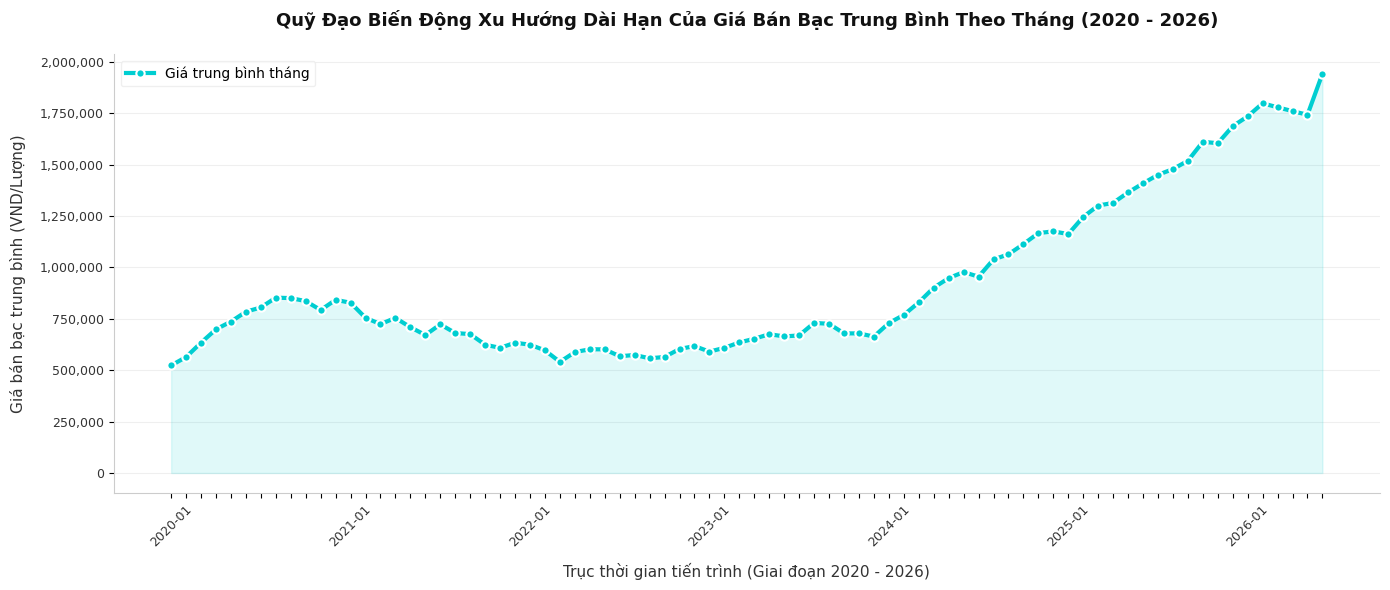

In [30]:
df_q4 = df.groupby(['Nam', 'Thang'])['Gia_Ban'].mean().reset_index()

# Tạo cột trục thời gian định dạng Chuỗi (Ví dụ: "2020-01", "2020-02"...) để hiển thị tuần tự
df_q4['Thoi_Gian'] = df_q4['Nam'].astype(str) + '-' + df_q4['Thang'].astype(str).str.zfill(2)
df_q4 = df_q4.sort_values('Thoi_Gian')

# SỬ DỤNG THEME NỀN TRẮNG SÁNG TIÊU CHUẨN
plt.style.use('default') 

# 2. Khởi tạo cấu hình giao diện đồ thị nền trắng
plt.figure(figsize=(14, 6), facecolor='#ffffff')
ax = plt.gca()
ax.set_facecolor('#ffffff')

# 3. Vẽ biểu đồ đường xu hướng ĐẬM SẮC NÉT
plt.plot(
    df_q4['Thoi_Gian'], 
    df_q4['Gia_Ban'], 
    color='#00ced1',       # Màu xanh ngọc lục bảo (Cyan) tương phản mạnh trên nền trắng
    linewidth=3.0,         # Tăng độ dày đường để nhìn rõ ràng, chắc chắn
    marker='o',            # Chấm tròn lớn tại các mốc tháng
    markersize=6,
    markerfacecolor='#00ced1',
    markeredgecolor='#ffffff', # Viền trắng bao quanh chấm để tạo điểm nhấn tách biệt với đường line
    markeredgewidth=1.5,
    label='Giá trung bình tháng',
    zorder=3
)

# ĐỔ BÓNG GRADIENT MỜ DƯỚI ĐƯỜNG (Giúp biểu đồ có chiều sâu, sáng sủa)
plt.fill_between(
    df_q4['Thoi_Gian'], 
    df_q4['Gia_Ban'], 
    color='#00ced1', 
    alpha=0.12,            # Độ mờ vừa phải để không làm tối biểu đồ
    zorder=2
)

# 4. Định dạng hiển thị trục X (Chỉ hiện nhãn của tháng 1 hàng năm để tránh dày đặc chữ)
x_ticks = df_q4['Thoi_Gian'].tolist()
visible_ticks = [label if '-01' in label else '' for label in x_ticks]
plt.xticks(range(len(x_ticks)), visible_ticks, rotation=45, fontsize=9, color='#333333')
plt.yticks(fontsize=9, color='#333333')

# 5. Cấu hình tiêu đề mới và hệ lưới mờ tinh tế
plt.title('Quỹ Đạo Biến Động Xu Hướng Dài Hạn Của Giá Bán Bạc Trung Bình Theo Tháng (2020 - 2026)', fontsize=13, fontweight='bold', pad=20, color='#111111')
plt.xlabel('Trục thời gian tiến trình (Giai đoạn 2020 - 2026)', fontsize=11, labelpad=10, color='#333333')
plt.ylabel('Giá bán bạc trung bình (VND/Lượng)', fontsize=11, labelpad=10, color='#333333')

# Định dạng hiển thị số tiền có dấu phẩy phân cách trực quan
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))

# Chỉnh đường lưới ngang mảnh, màu xám rất nhạt (Tránh kẻ ô vuông gây rối mắt)
plt.grid(True, axis='y', linestyle='-', alpha=0.3, color='#cccccc', zorder=1)

# LOẠI BỎ VIỀN HỘP BIỂU ĐỒ (Tạo không gian mở, hiện đại)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')   # Làm mờ đường viền trục dọc
ax.spines['bottom'].set_color('#cccccc') # Làm mờ đường viền trục ngang

# Tùy chỉnh hộp chú thích tối giản
plt.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#ececec', fontsize=10)

# 6. Tối ưu hóa viền và xuất file ảnh hệ thống
plt.tight_layout()
plt.savefig('cau3_hinh3_4_xu_huong.png', dpi=300, facecolor='#ffffff', edgecolor='none')
plt.show()


# HÌNH 3.5

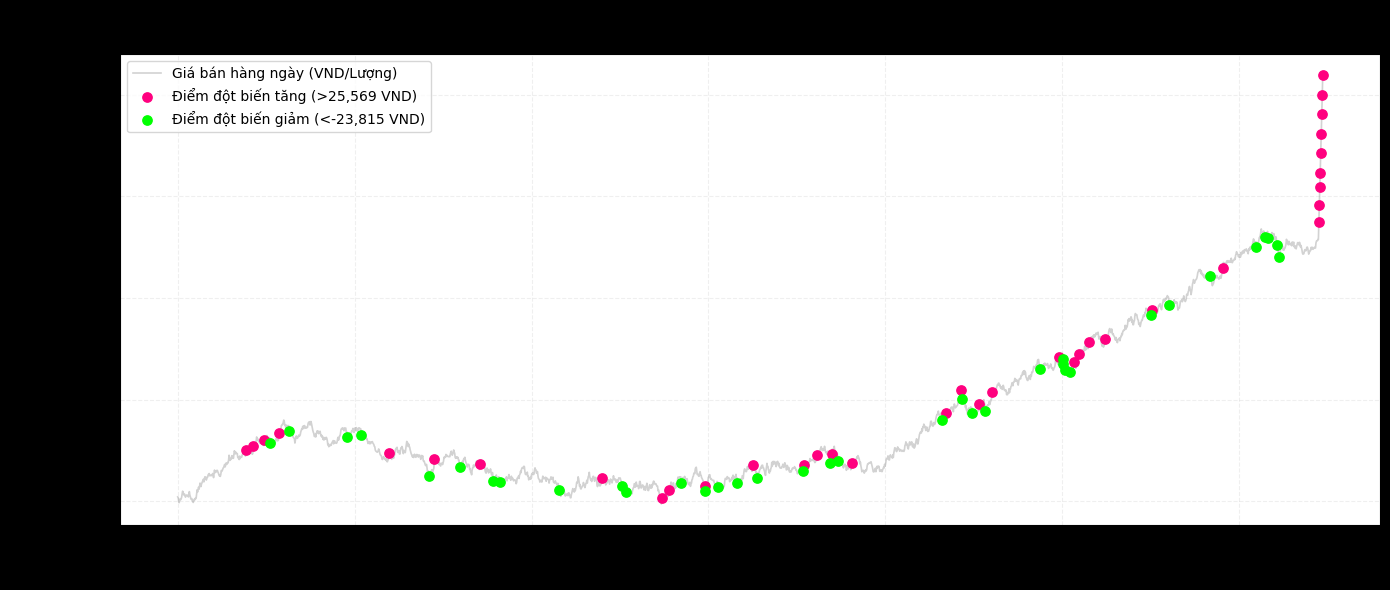

-> Đã xuất biểu đồ Hình 3.5. Phát hiện 36 phiên tăng sốc và 36 phiên giảm sâu dựa trên số liệu thực tế.


In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

df = df.sort_values("Ngay").reset_index(drop=True)
df["Ngay_dt"] = pd.to_datetime(df["Ngay"])

df["Bien_Dong_Hang_Ngay"] = df["Gia_Ban"].diff()

mean_bd = df["Bien_Dong_Hang_Ngay"].mean()
std_bd = df["Bien_Dong_Hang_Ngay"].std()

nguong_tren = mean_bd + 2 * std_bd
nguong_duoi = mean_bd - 2 * std_bd

df_tang_doc = df[df["Bien_Dong_Hang_Ngay"] > nguong_tren]
df_giam_soc = df[df["Bien_Dong_Hang_Ngay"] < nguong_duoi]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    df["Ngay_dt"],
    df["Gia_Ban"],
    color="gray",
    alpha=0.35,
    linewidth=1.2,
    label="Giá bán hàng ngày (VND/Lượng)",
)

ax.scatter(
    df_tang_doc["Ngay_dt"],
    df_tang_doc["Gia_Ban"],
    color="red",
    s=45,
    zorder=5,
    label=f"Điểm đột biến tăng (>{int(nguong_tren):,} VND)",
)

ax.scatter(
    df_giam_soc["Ngay_dt"],
    df_giam_soc["Gia_Ban"],
    color="green",
    s=45,
    zorder=5,
    label=f"Điểm đột biến giảm (<{int(nguong_duoi):,} VND)",
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=0, fontsize=10)

plt.title(
    "Bản đồ phát hiện các ngày biến động giá bạc đột biến (2020 - 2026)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.xlabel("Năm", fontsize=11)
plt.ylabel("Giá bán bạc (VND/Lượng)", fontsize=11)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

plt.grid(True, linestyle="--", alpha=0.2)
plt.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("cau3_hinh3_5_dot_bien_chuan.png", dpi=300)
plt.show()

print(
    f"Đã phát hiện {len(df_tang_doc)} phiên tăng sốc và {len(df_giam_soc)} phiên giảm sâu."
)